# 04 · Find a misaligned raster before it enters analysis

Combine Sentinel-2 spectral bands and ESA WorldCover 2021 to inspect grid contracts and demonstrate why continuous and categorical variables need different resampling.

[Notebook index](README.md) · [Companion article](../docs/articles/geospatial-data-contracts.md) · [Data sources and licences](../docs/DATA_SOURCES.md)

Run every cell from top to bottom in the locked Python 3.12 environment. The first run downloads the required public data pack and checks its SHA-256. Generated artifacts remain in the ignored `outputs/` directory.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython import get_ipython
from IPython.display import display

from geoai_portfolio.io import ensure_data

get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "figure.figsize": (10, 4),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelsize": 9,
        "axes.titlesize": 11,
        "font.size": 10,
        "savefig.bbox": "tight",
    }
)
pd.set_option("display.precision", 4)

In [2]:
import rasterio
from affine import Affine
from rasterio.io import MemoryFile

from geoai_portfolio.rasters import align, map_array, require_same_grid

data = ensure_data("satellite")
rows = []
for name in ["before.tif", "swir20m.tif", "worldcover.tif"]:
    with rasterio.open(data / name) as source:
        rows.append(
            {
                "file": name,
                "crs": str(source.crs),
                "shape": source.shape,
                "resolution": source.res,
                "nodata": source.nodata,
                "bands": source.descriptions,
            }
        )
display(pd.DataFrame(rows))

,file,crs,shape,resolution,nodata,bands
0,before.tif,EPSG:32610,"(512, 512)","(10.0, 10.0)",0.0,"(red, green, blue, nir)"
1,swir20m.tif,EPSG:32610,"(256, 256)","(20.0, 20.0)",0.0,"(B12,)"
2,worldcover.tif,EPSG:4326,"(565, 736)","(8.333333333333333e-05, 8.333333333333333e-05)",0.0,"(ESA WorldCover 2021 v200 class,)"


## Test an intentional contract violation

Equal array shapes do not establish alignment. The following in-memory copy moves the
affine origin by half a pixel, preserving the CRS and pixel count. The original public
file remains unchanged. An early error is the desired result.

In [3]:
with rasterio.open(data / "before.tif") as source, MemoryFile() as memory:
    profile = source.profile.copy()
    profile["transform"] = source.transform @ Affine.translation(0.5, 0)
    with memory.open(**profile) as shifted:
        shifted.write(source.read())
        try:
            require_same_grid(source, shifted)
        except ValueError as error:
            print("Expected contract rejection:", error)
        else:
            raise AssertionError("Shifted grid was accepted")

Expected contract rejection: Grid mismatch: CRS, shape, or affine transform differs


## Match resampling to the variable

B12 is a continuous 20 m measurement, so bilinear interpolation can place it on the
reference grid. Interpolation adds no independent 10 m information. WorldCover is a
categorical 2021 v200 map in geographic coordinates: nearest neighbour preserves labels.
Its classes are context for the contract example, not ground truth for EuroSAT or a
validation of vegetation change. Even though its name includes “10m”, its angular grid
is not identical to Sentinel's UTM grid at this latitude.

In [4]:
swir = align(data / "swir20m.tif", data / "before.tif", categorical=False)
with rasterio.open(data / "swir20m.tif") as source:
    swir = swir * source.scales[0] + source.offsets[0]
labels = align(data / "worldcover.tif", data / "before.tif", categorical=True)
wrong = align(data / "worldcover.tif", data / "before.tif", categorical=False)
with rasterio.open(data / "worldcover.tif") as source:
    source_labels = np.unique(source.read(1, masked=True).compressed())
assert set(np.unique(labels.compressed())).issubset(set(source_labels))
fractional = np.abs(wrong.compressed() - np.round(wrong.compressed())) > 1e-5
display(
    pd.DataFrame(
        {
            "check": ["Source classes", "Nearest output classes", "Fractional bilinear values"],
            "value": [
                str(source_labels.tolist()),
                str(np.unique(labels.compressed()).tolist()),
                str(int(fractional.sum())),
            ],
        }
    )
)

,check,value
0,Source classes,"[10, 30, 50, 60]"
1,Nearest output classes,"[10.0, 30.0, 50.0, 60.0]"
2,Fractional bilinear values,8390


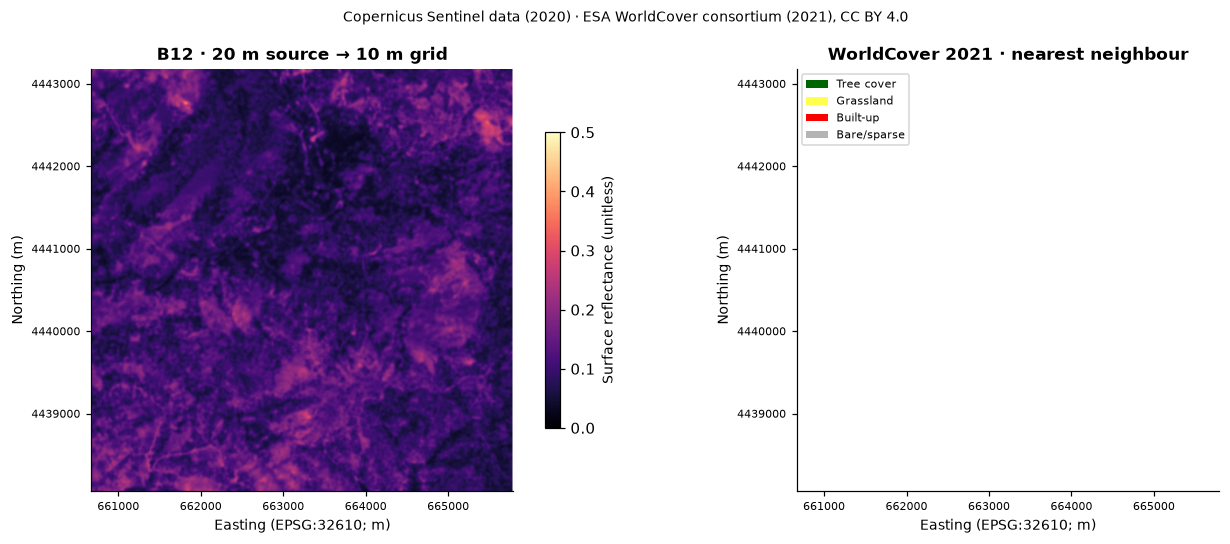

In [5]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

classes = {
    10: ("Tree cover", "#006400"),
    20: ("Shrubland", "#ffbb22"),
    30: ("Grassland", "#ffff4c"),
    40: ("Cropland", "#f096ff"),
    50: ("Built-up", "#fa0000"),
    60: ("Bare/sparse", "#b4b4b4"),
    70: ("Snow/ice", "#f0f0f0"),
    80: ("Water", "#0064c8"),
    90: ("Wetland", "#0096a0"),
    95: ("Mangroves", "#00cf75"),
    100: ("Moss/lichen", "#fae6a0"),
}
encoded = np.ma.masked_all(labels.shape)
for index, category in enumerate(classes):
    encoded[labels == category] = index
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
with rasterio.open(data / "before.tif") as reference:
    image = map_array(axes[0], swir, reference, "B12 · 20 m source → 10 m grid", "magma", 0, 0.5)
    fig.colorbar(image, ax=axes[0], label="Surface reflectance (unitless)", shrink=0.7)
    map_array(
        axes[1],
        encoded,
        reference,
        "WorldCover 2021 · nearest neighbour",
        ListedColormap([v[1] for v in classes.values()]),
        -0.5,
        len(classes) - 0.5,
    )
axes[1].legend(
    handles=[
        Patch(facecolor=color, label=name)
        for value, (name, color) in classes.items()
        if value in source_labels
    ],
    loc="upper left",
    fontsize=7,
)
fig.suptitle(
    "Copernicus Sentinel data (2020) · ESA WorldCover consortium (2021), CC BY 4.0", fontsize=9
)
plt.tight_layout()
plt.show()

## Contract carried downstream

Record the CRS, affine transform, shape, band order, nodata meaning, units, source version
and resampling choice together. Masking is part of the contract. A newly introduced
fractional class code is evidence of an invalid processing choice, even if the plot
looks smooth. [Rasterio reprojection](https://rasterio.readthedocs.io/en/stable/topics/reproject.html)
and the [WorldCover product documentation](https://esa-worldcover.org/en/data-access)
provide the source conventions used here.